In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Lifted Interpolant — Drift + Conditional Flow Map (CM E-step)

Variant of `lifted_2dtoys.ipynb` that replaces the expensive 64-step RK3 E-step with a **conditional flow map model** (`model_cm`) trained online via Flow Map Matching (FMM).

**Key change:** Per outer iteration, `phi_k` is run once to generate teacher pairs `(z, y_real, x_em_teacher)`. A conditional consistency model `model_cm` is updated for `n_cm_steps` gradient steps. All `t_inner` inner E-steps then use `model_cm` for a single forward pass.

Linear interpolant: `I_t = (1-t)·x0' + t·X_1(x0)`. Drift target:
$$
\mathcal L = \mathbb E\,\|\hat b^\theta_t(I_t, y) - (X_1 - X_0')\|^2.
$$

Consistency model flow map:
$$
X_{s,t}(x \mid y) = x + (t-s)\,v_\theta(x, y, s, t).
$$

Trained with consistency + invertibility losses from FMM (`consistency.py`).

# Problem: AWGN + 2D toy data

In [2]:
def forward_corruption(x, noise_std=0.1):
    return x + noise_std * torch.randn_like(x)

def sample_clean(n, kind="two_moons", device=device):
    if kind == "two_moons":
        n1 = n // 2
        n2 = n - n1
        t1 = torch.rand(n1, device=device) * torch.pi
        t2 = torch.rand(n2, device=device) * torch.pi
        a = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1)
        b = torch.stack([1 - torch.cos(t2), 1 - torch.sin(t2) - 0.5], dim=1)
        y = torch.cat([a, b], dim=0) + 0.05 * torch.randn(n, 2, device=device)
        return y[torch.randperm(n, device=device)]
    if kind == "checkerboard":
        y = 4 * torch.rand(n, 2, device=device) - 2
        y[:, 1] += ((torch.floor(y[:, 0]) + torch.floor(y[:, 1])) % 2) * 0.5 - 0.25
        return y
    raise ValueError(f"Unknown kind: {kind}")

def sample_corrupted(n, kind="two_moons", noise_std=0.1, device=device):
    y = sample_clean(n, kind, device)
    return forward_corruption(y, noise_std)

### Visualization

In [3]:
def visualize_compare(
    model_cm,
    model_oracle,
    data_kind,
    noise_std,
    n_vis=1024,
    title_prefix="",
    loss_cm=None,
    loss_oracle=None,
):
    cm_was_training = model_cm.training
    or_was_training = model_oracle.training
    model_cm.eval(); model_oracle.eval()
    with torch.no_grad():
        z = torch.randn(n_vis, 2, device=device)
        clean = sample_clean(n_vis, data_kind, device)
        corrupted = forward_corruption(clean, noise_std)
        samples_cm = fast_e_step(model_cm, z, corrupted)
        samples_or = flow(model_oracle, z, corrupted)

    fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))

    all_pts = torch.cat([clean, corrupted, samples_cm, samples_or], dim=0).detach().cpu()
    pad = 0.15
    xmin, xmax = all_pts[:, 0].min().item(), all_pts[:, 0].max().item()
    ymin, ymax = all_pts[:, 1].min().item(), all_pts[:, 1].max().item()
    dx, dy = xmax - xmin, ymax - ymin
    xmin, xmax = xmin - pad * dx, xmax + pad * dx
    ymin, ymax = ymin - pad * dy, ymax + pad * dy

    titles = ("Clean", "Corrupted", "CM (1-step)", "Oracle ODE flow")
    datasets = (clean, corrupted, samples_cm, samples_or)
    for ax, title, data in zip(axes[:4], titles, datasets):
        x, y = data[:, 0].detach().cpu(), data[:, 1].detach().cpu()
        ax.scatter(x, y, s=8, alpha=0.7)
        ax.set_title(title)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("$x_1$")
    axes[0].set_ylabel("$x_2$")

    loss_ax = axes[4]
    loss_ax.set_title("Loss (log-log)")
    if loss_cm is not None and len(loss_cm) > 0:
        steps = torch.arange(1, len(loss_cm) + 1, device="cpu").numpy()
        losses = torch.tensor(loss_cm, dtype=torch.float32).clamp_min(1e-12).numpy()
        loss_ax.loglog(steps, losses, linewidth=1.2, label="CM (FMM)", color="tab:blue", alpha=0.8)
    if loss_oracle is not None and len(loss_oracle) > 0:
        steps = torch.arange(1, len(loss_oracle) + 1, device="cpu").numpy()
        losses = torch.tensor(loss_oracle, dtype=torch.float32).clamp_min(1e-12).numpy()
        loss_ax.loglog(steps, losses, linewidth=1.2, label="Oracle", color="tab:orange", alpha=0.8)
    loss_ax.set_xlabel("step")
    loss_ax.set_ylabel("loss")
    loss_ax.grid(True, alpha=0.3, which="both")
    loss_ax.legend(loc="upper right")

    if title_prefix:
        fig.suptitle(title_prefix)
        fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    else:
        fig.tight_layout()

    clear_output(wait=True)
    display(fig)

    if cm_was_training: model_cm.train()
    if or_was_training: model_oracle.train()

    return fig, axes

# Lifted SCSI Setup — Conditional Flow Map as the EM Model

A single `model_cm` (conditional flow map) replaces `model_em` (drift model) entirely.

**E-step**: single forward pass through frozen `phi_k`:
$$
x_\text{em} = X_{0,1}^\theta(z \mid y_\text{real}), \qquad z \sim \mathcal N(0, I).
$$

**M-step**: FMM loss on the linear interpolant from `z'` to `x_em`, conditioned on `y_cond`:
$$
\mathcal{L}_\text{CM} = \underbrace{\left\|\frac{d}{dt}X_{s,t}(X_{t,s}(I_t \mid y) \mid y) - (x_\text{em} - z')\right\|^2}_{\text{consistency}} + \underbrace{\left\|X_{s,t}(X_{t,s}(I_t \mid y) \mid y) - I_t\right\|^2}_{\text{invertibility}}, \quad I_t = (1-t)z' + t\,x_\text{em}.
$$

`y_cond` uses the `y_fake_ratio` mix as before: a fraction of the batch is conditioned on `y_fake = F(x_em)` (Choice 2), the rest on `y_real` (Choice 1).

After each outer iteration `phi_k ← model_cm`.

In [4]:
class SimpleMLP(nn.Module):
    def __init__(self, x_dim=2, y_dim=2, hidden=128*2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim + y_dim + 1, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, x_dim)
        )

    def forward(self, x_t, y_cond, t):
        return self.net(torch.cat([x_t, y_cond, t], dim=1))


def drift(model_fixed, x, y, t):
    # Direct drift parameterization — the network output IS b_t(x, y).
    return model_fixed(x, y, t)


def flow(model_fixed, z, y, n_steps=64, t_eps=0.0):
    '''Ralston's RK3 integrator on t in [0, 1 - t_eps].

    Stages:  k1 at (t, x)
             k2 at (t + dt/2, x + (dt/2) k1)
             k3 at (t + 3 dt/4, x + (3 dt/4) k2)
    Update:  x_{n+1} = x + dt * (2/9 k1 + 1/3 k2 + 4/9 k3)
    '''
    x = z
    t_final = 1.0 - t_eps
    dt = t_final / n_steps
    for s in range(n_steps):
        t0 = torch.full((z.size(0), 1), s * dt, device=z.device)
        k1 = drift(model_fixed, x, y, t0)
        t_mid = t0 + 0.5 * dt
        k2 = drift(model_fixed, x + 0.5 * dt * k1, y, t_mid)
        t_3q = t0 + 0.75 * dt
        k3 = drift(model_fixed, x + 0.75 * dt * k2, y, t_3q)
        x_new = x + dt * (2.0 / 9.0 * k1 + 1.0 / 3.0 * k2 + 4.0 / 9.0 * k3)
        x = x_new
    if (
        torch.isnan(x_new).any()
        or torch.isinf(x_new).any()
        or torch.isnan(k1).any()
        or torch.isinf(k1).any()
        or torch.isnan(k2).any()
        or torch.isinf(k2).any()
        or torch.isnan(k3).any()
        or torch.isinf(k3).any()
    ):
        print(f"[Numerical Error @ step {s}]: nan/inf detected in flow()!")
        print(f"x: {x}")
        print(f"k1: {k1}")
        print(f"k2: {k2}")
        print(f"k3: {k3}")
        print(f"x_new: {x_new}")
    return x

In [5]:
# ── Conditional Flow Map Model (FMM framework from consistency.py) ──────────

class SinusoidalEmbedding(nn.Module):
    """Maps scalar times [B] → sinusoidal embeddings [B, dim]."""
    def __init__(self, dim: int):
        super().__init__()
        assert dim % 2 == 0
        half = dim // 2
        freqs = torch.exp(-math.log(10_000.0) * torch.arange(half) / half)
        self.register_buffer("freqs", freqs, persistent=False)

    def forward(self, t: torch.Tensor) -> torch.Tensor:  # t: [B]
        ang = t[:, None] * self.freqs[None, :] * 2 * math.pi
        return torch.cat([torch.sin(ang), torch.cos(ang)], dim=-1)


class ConditionalFlowMapMLP(nn.Module):
    """
    Conditional two-time flow map surrogate for the EM E-step.

    velocity:  v_theta(x, y, s, t)                            [B, data_dim]
    flow_map:  X_{s,t}(x | y) = x + (t - s) * v_theta(...)   [B, data_dim]

    Times s, t are [B, 1] (notebook convention).
    Network input: [x(data_dim) | y(y_dim) | s_emb(t_embed_dim) | t_emb(t_embed_dim)]
    """
    def __init__(self, data_dim=2, y_dim=2, hidden=128, n_layers=3, t_embed_dim=16):
        super().__init__()
        self.s_embed = SinusoidalEmbedding(t_embed_dim)
        self.t_embed = SinusoidalEmbedding(t_embed_dim)
        in_dim = data_dim + y_dim + 2 * t_embed_dim
        layers = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, data_dim)]
        self.net = nn.Sequential(*layers)

    def velocity(self, x, y, s, t):
        # x, y: [B, 2];  s, t: [B, 1]  →  squeeze to [B] for SinusoidalEmbedding
        s_e = self.s_embed(s.squeeze(-1))   # [B, t_embed_dim]
        t_e = self.t_embed(t.squeeze(-1))   # [B, t_embed_dim]
        return self.net(torch.cat([x, y, s_e, t_e], dim=-1))  # [B, data_dim]

    def flow_map(self, x, y, s, t):
        # (t - s): [B, 1] broadcasts against velocity [B, data_dim]
        return x + (t - s) * self.velocity(x, y, s, t)


def conditional_fmm_loss(model, x0, x1, y_cond, strip_width=0.25, min_gap=0.02):
    """
    Flow Map Matching loss for the conditional E-step surrogate.

    x0:     [B, 2]  Gaussian noise (z_teacher, detached)
    x1:     [B, 2]  teacher E-step output x_em_teacher (no grad)
    y_cond: [B, 2]  corrupted observations y_teacher

    Minimises consistency + invertibility of X_{s,t}(·|y) along the
    linear interpolant I_t = (1-t)*x0 + t*x1.
    """
    B, dev = x0.shape[0], x0.device

    # Sample (s, t) with |t - s| ∈ [min_gap, strip_width]; shapes [B, 1]
    s   = torch.rand(B, 1, device=dev)
    mag = min_gap + (strip_width - min_gap) * torch.rand(B, 1, device=dev)
    sign = torch.where(
        torch.rand(B, 1, device=dev) < 0.5,
        -torch.ones(B, 1, device=dev),
         torch.ones(B, 1, device=dev),
    )
    t = (s + sign * mag).clamp(0.0, 1.0)

    I_t   = (1.0 - t) * x0 + t * x1   # [B, 2]
    dI_dt = x1 - x0                     # [B, 2]  (velocity of the interpolant)

    # Backward leg: push I_t from t → s
    y_back = model.flow_map(I_t, y_cond, t, s)   # [B, 2]

    # Forward leg + JVP over t: compute X_{s,t}(y_back | y_cond) and d/dt of it
    # y_back and y_cond are captured in the closure; only t_in is differentiated.
    def fwd(t_in):
        return model.flow_map(y_back, y_cond, s, t_in)

    z_fwd, dz_dt = torch.func.jvp(fwd, (t,), (torch.ones_like(t),))

    consistency   = ((dz_dt - dI_dt) ** 2).sum(dim=-1).mean()
    invertibility = ((z_fwd - I_t)   ** 2).sum(dim=-1).mean()
    return consistency + invertibility


@torch.no_grad()
def fast_e_step(model, z, y, n_steps=1):
    """
    Few-step E-step via the learned conditional flow map.

    n_steps=1: single forward pass X_{0,1}(z | y)  (consistency model regime).
    n_steps>1: chain n equal jumps X_{k/n,(k+1)/n}.
    Times are [B, 1] throughout.
    """
    B, dev = z.shape[0], z.device
    model.eval()
    x = z
    times = torch.linspace(0.0, 1.0, n_steps + 1, device=dev)
    for k in range(n_steps):
        s = times[k    ].expand(B).unsqueeze(-1)   # [B, 1]
        t = times[k + 1].expand(B).unsqueeze(-1)   # [B, 1]
        x = model.flow_map(x, y, s, t)
    return x

In [ ]:
# Problem Parameters
data_kind = "two_moons"  # "two_moons" or "checkerboard"
noise_std = 0.1

# EM-only knobs
y_fake_ratio   = 1.0    # Fraction of CM batch conditioned on y_fake (Choice 2). 1.0 = pure Choice 2.
x0_independent = True   # True: z' ⊥ z (fresh noise for FMM interpolant). False: z' = z.

# SCSI Parameters
t_outer, t_inner = 5_000, 10

# Training Parameters
batch_size    = 516
max_grad_norm = 1.0
base_lr       = 1e-4
min_lr        = 1e-6

# Consistency model knobs
n_steps_cm_infer = 5    # E-step inference steps: 1 = single-shot flow map
cm_strip_width   = 0.25
cm_min_gap       = 0.02
base_lr_cm       = 1e-3
min_lr_cm        = 1e-4


# Logging Parameters
print_every  = 100       # Print loss every N global steps (0 to disable).
sample_every = 5000      # Refresh visualization every N global steps.
n_vis        = 1024

# Oracle drift model (supervised baseline, unchanged).
model_oracle = SimpleMLP(hidden=516).to(device)
opt_oracle   = torch.optim.Adam(model_oracle.parameters(), lr=base_lr)
sched_oracle = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_oracle, T_max=max(t_outer * t_inner, 1), eta_min=min_lr
)

# Conditional flow map model — the sole EM model.
model_cm = ConditionalFlowMapMLP(
    data_dim=2, y_dim=2, hidden=256, n_layers=4, t_embed_dim=16
).to(device)
opt_cm = torch.optim.Adam(model_cm.parameters(), lr=base_lr_cm, weight_decay=1e-4, eps=1e-8)
sched_cm = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_cm, T_max=max(t_outer * t_inner, 1), eta_min=min_lr_cm
)

global_step         = 0
loss_history_cm     = []
loss_history_oracle = []

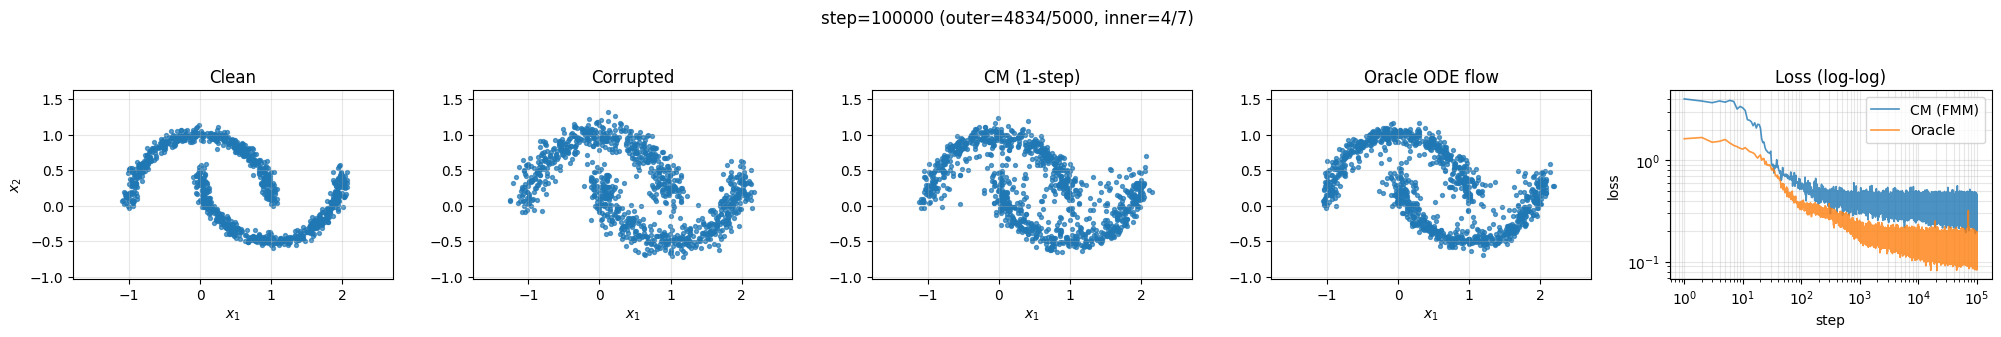

step=100100 (outer=4848/5000) loss_cm=0.3346  loss_or=0.151023lr_cm=0.000600  lr_or=0.000100
step=100200 (outer=4863/5000) loss_cm=0.3821  loss_or=0.112010lr_cm=0.000600  lr_or=0.000100
step=100300 (outer=4877/5000) loss_cm=0.2814  loss_or=0.120050lr_cm=0.000600  lr_or=0.000100
step=100400 (outer=4891/5000) loss_cm=0.3294  loss_or=0.119186lr_cm=0.000600  lr_or=0.000100
step=100500 (outer=4905/5000) loss_cm=0.3414  loss_or=0.149281lr_cm=0.000600  lr_or=0.000100
step=100600 (outer=4920/5000) loss_cm=0.3383  loss_or=0.108867lr_cm=0.000600  lr_or=0.000100
step=100700 (outer=4934/5000) loss_cm=0.2841  loss_or=0.124857lr_cm=0.000600  lr_or=0.000100
step=100800 (outer=4948/5000) loss_cm=0.4004  loss_or=0.152355lr_cm=0.000600  lr_or=0.000100
step=100900 (outer=4963/5000) loss_cm=0.3837  loss_or=0.147153lr_cm=0.000600  lr_or=0.000100
step=101000 (outer=4977/5000) loss_cm=0.3600  loss_or=0.124329lr_cm=0.000600  lr_or=0.000100
step=101100 (outer=4991/5000) loss_cm=0.3237  loss_or=0.124469lr_cm=0.

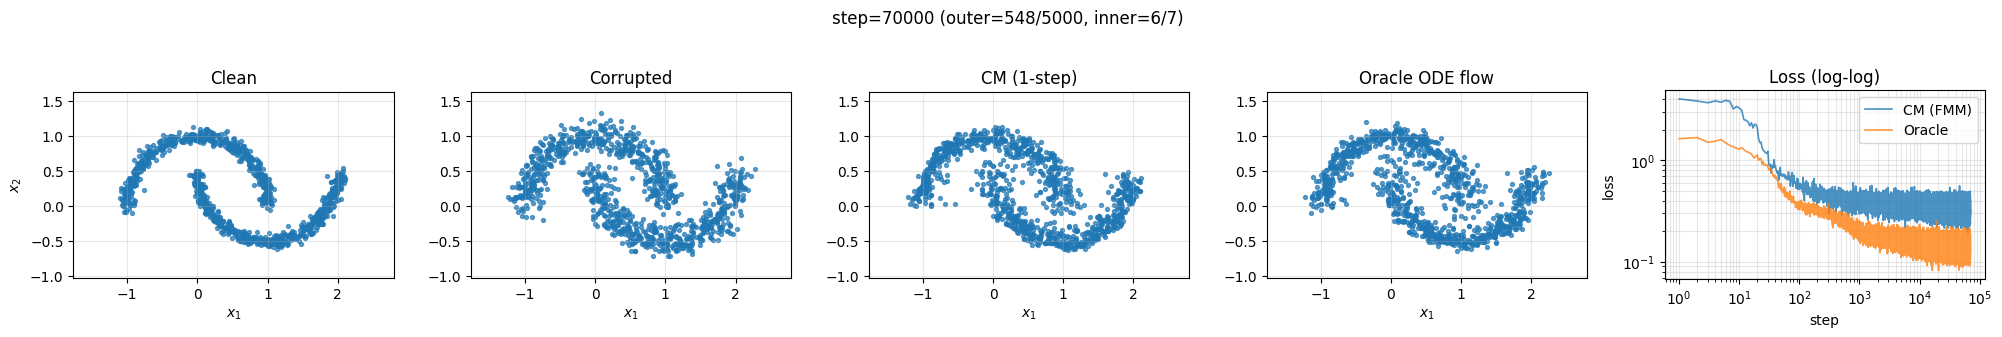

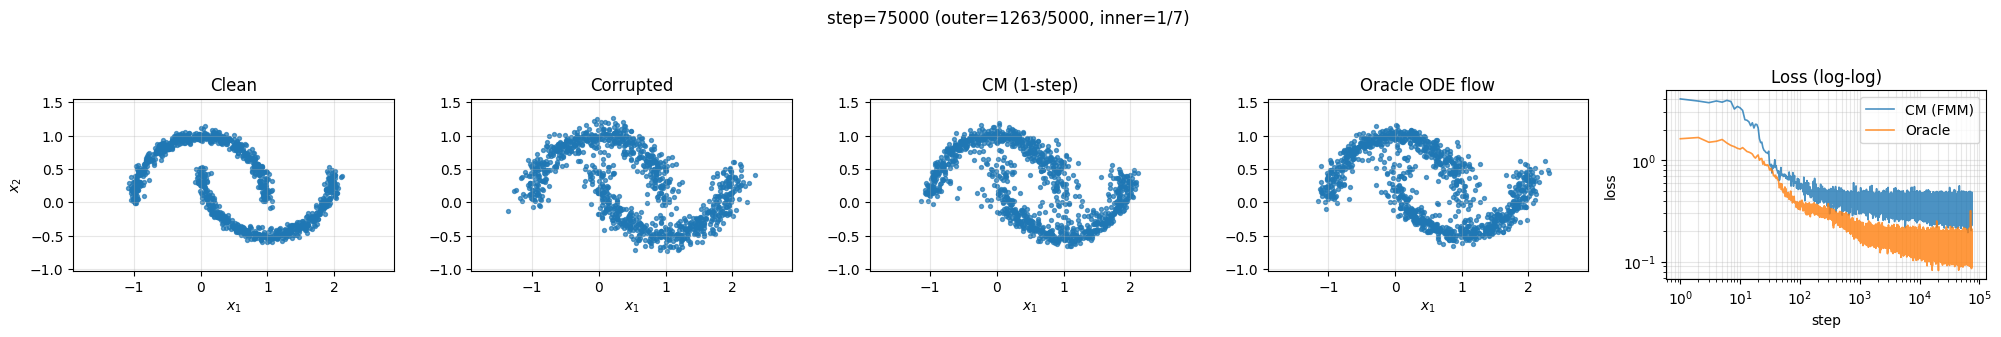

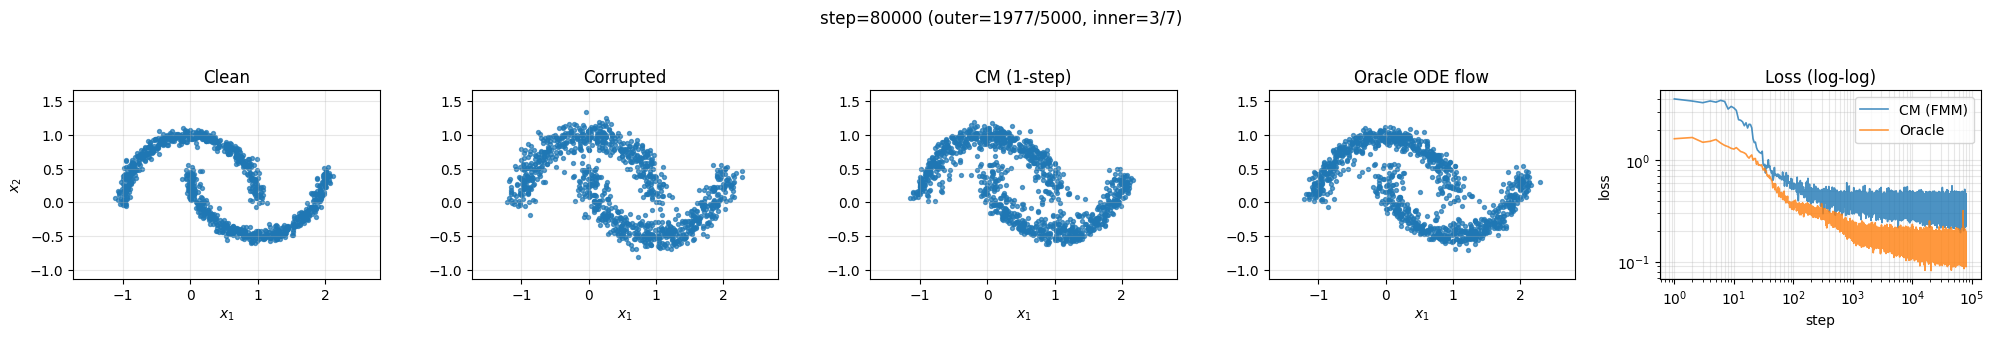

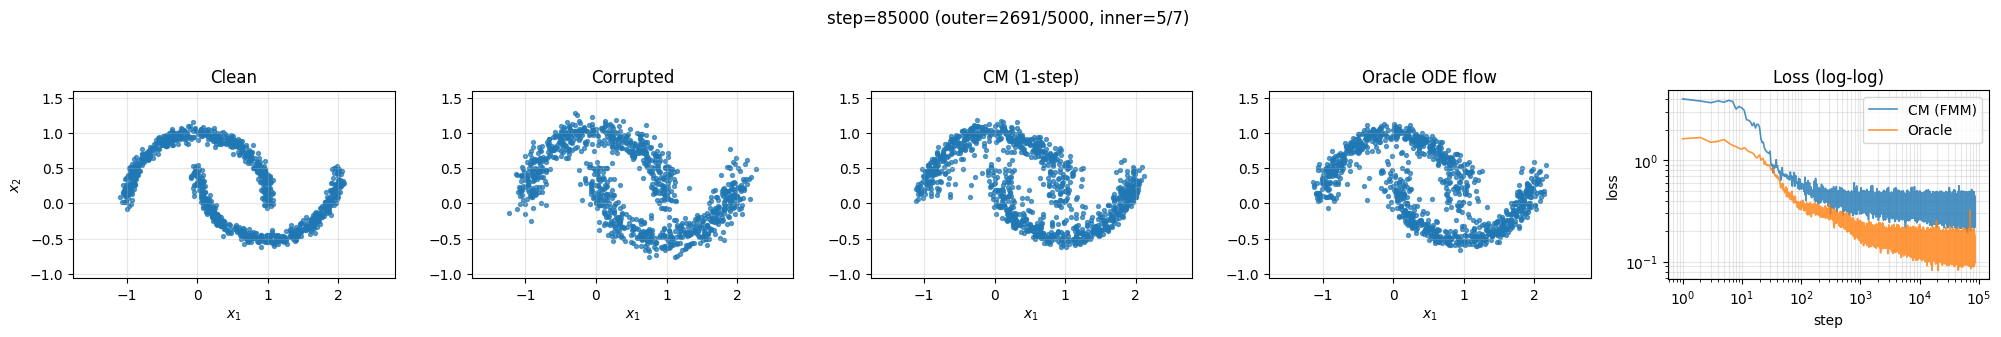

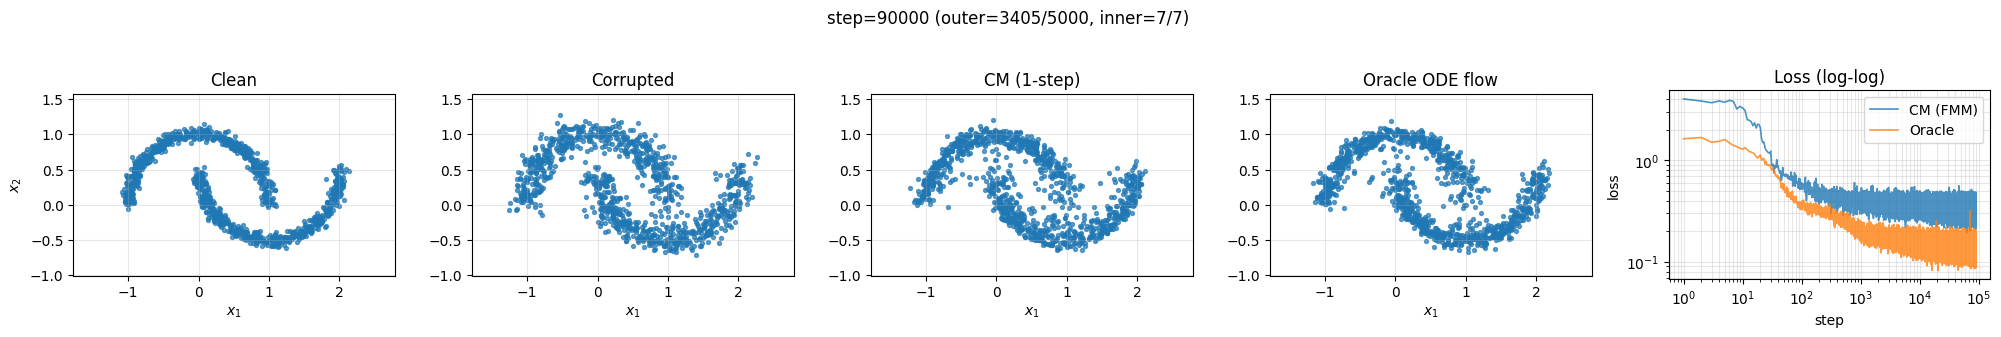

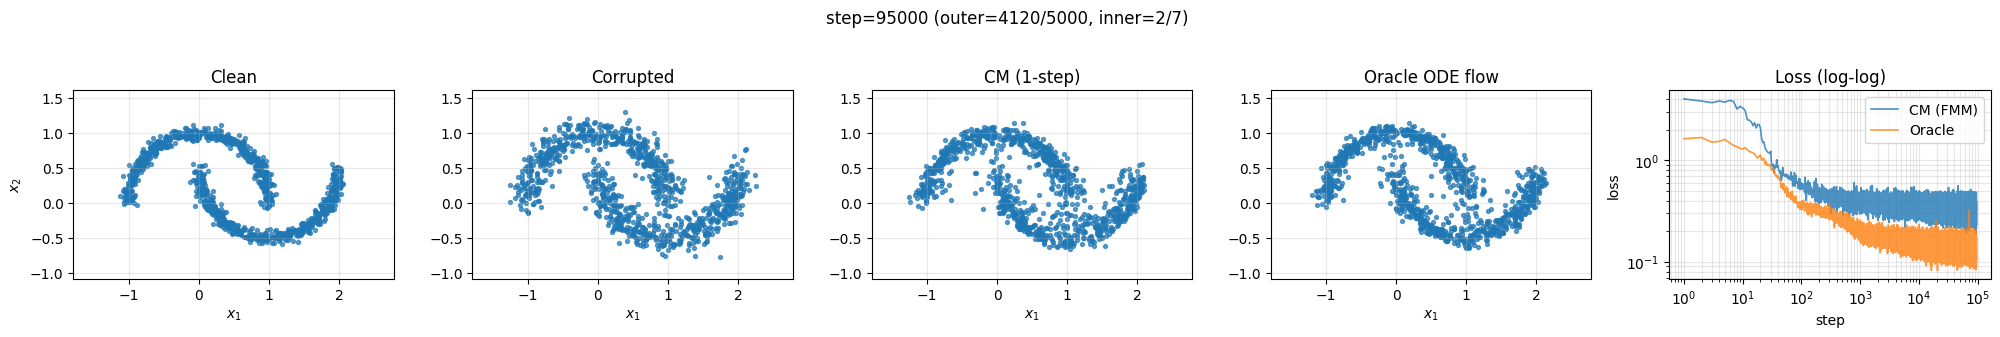

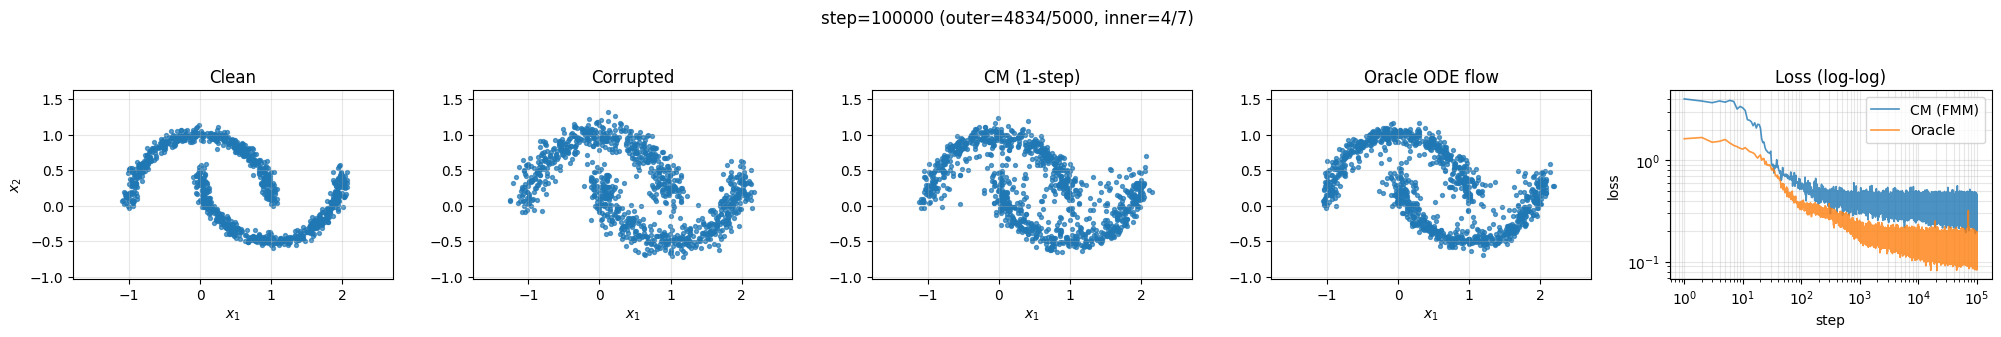

In [21]:
t_inner = 7
y_fake_ratio   = 1.0
opt_cm = torch.optim.Adam(model_cm.parameters(), lr=6e-4, weight_decay=1e-4, eps=1e-8)
sched_cm = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_cm, T_max=max(t_outer * t_inner, 1), eta_min=6e-4
)

phi_k = copy.deepcopy(model_cm).eval()

for k in range(t_outer):
    for i in range(t_inner):
        # Shared randomness.
        z       = torch.randn(batch_size, 2, device=device)
        t       = torch.rand(batch_size, 1, device=device)
        z_prime = torch.randn(batch_size, 2, device=device) if x0_independent else z

        # ── Oracle branch (supervised drift model, unchanged) ────────────────
        model_oracle.train()
        opt_oracle.zero_grad()
        x_clean     = sample_clean(batch_size, data_kind, device)
        y_oracle    = forward_corruption(x_clean, noise_std)
        I_t_or      = (1 - t) * z_prime + t * x_clean
        b_target_or = x_clean - z_prime
        b_hat_or    = model_oracle(I_t_or, y_oracle, t)
        loss_or     = ((b_hat_or - b_target_or) ** 2).mean()
        loss_or.backward()
        torch.nn.utils.clip_grad_norm_(model_oracle.parameters(), max_grad_norm)
        opt_oracle.step()
        sched_oracle.step()
        loss_history_oracle.append(loss_or.item())

        # ── CM branch (unsupervised EM flow map) ─────────────────────────────
        model_cm.train()
        opt_cm.zero_grad(set_to_none=True)

        y_real = sample_corrupted(batch_size, data_kind, noise_std, device)

        # E-step: single forward pass through frozen phi_k.
        x_em   = fast_e_step(phi_k, z, y_real, n_steps=n_steps_cm_infer)
        y_fake = forward_corruption(x_em, noise_std)

        # y_cond: deterministic mix of y_fake (Choice 2) and y_real (Choice 1).
        n_fake = max(0, min(int(batch_size * y_fake_ratio), batch_size))
        if n_fake == 0:
            y_cond = y_real
        elif n_fake == batch_size:
            y_cond = y_fake
        else:
            y_cond = torch.cat((y_fake[:n_fake], y_real[n_fake:]), dim=0)

        # M-step: FMM consistency + invertibility loss.
        # Interpolant: I_t = (1-t)*z' + t*x_em, conditioned on y_cond.
        loss_cm = conditional_fmm_loss(
            model_cm, z_prime, x_em, y_cond,
            strip_width=cm_strip_width, min_gap=cm_min_gap,
        )

        if torch.isfinite(loss_cm):
            loss_cm.backward()
            torch.nn.utils.clip_grad_norm_(model_cm.parameters(), max_grad_norm)
            opt_cm.step()
            sched_cm.step()

        loss_history_cm.append(loss_cm.item() if torch.isfinite(loss_cm) else float("nan"))

        global_step += 1

        if print_every > 0 and global_step % print_every == 0:
            current_lr_cm = opt_cm.param_groups[0]["lr"]
            current_lr_or = opt_oracle.param_groups[0]["lr"]
            print(
                f"step={global_step} (outer={k + 1}/{t_outer}) "
                f"loss_cm={loss_history_cm[-1]:.4f}  loss_or={loss_or.item():.6f}"
                f"lr_cm={current_lr_cm:.6f}  lr_or={current_lr_or:.6f}"
            )

        if sample_every > 0 and global_step % sample_every == 0:
            visualize_compare(
                model_cm,
                model_oracle,
                data_kind,
                noise_std,
                title_prefix=(
                    f"step={global_step} "
                    f"(outer={k + 1}/{t_outer}, inner={i + 1}/{t_inner})"
                ),
                n_vis=n_vis,
                loss_cm=loss_history_cm,
                loss_oracle=loss_history_oracle,
            )

    phi_k = copy.deepcopy(model_cm).eval()

This runs ~2x faster than the original ODE formulation